<a href="https://colab.research.google.com/github/MajorProjectBE-25/Ship-Detection/blob/main/Updated_AKS_with_model_graphs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Step 1: Install Kaggle API
!pip install -q kaggle

# Step 2: Upload Kaggle API Key
from google.colab import files

# Upload the kaggle.json file you downloaded from your Kaggle account
print("Upload kaggle.json:")
uploaded = files.upload()

# Step 3: Move the API Key to the proper location and set permissions
import os
import shutil

# Create .kaggle folder in your home directory
os.makedirs('/root/.kaggle', exist_ok=True)

# Move the uploaded kaggle.json file to the .kaggle directory
for filename in uploaded.keys():
    shutil.move(filename, '/root/.kaggle/kaggle.json')

# Set the file permissions to secure the API key
os.chmod('/root/.kaggle/kaggle.json', 600)

# Step 4: Download the dataset
competition_name = "airbus-ship-detection"

!kaggle competitions download -c $competition_name --force

# Step 5: Extract the dataset
import zipfile

# Update zip filename for the downloaded dataset
zip_file = f"{competition_name}.zip"

# Ensure the file exists before trying to extract
if os.path.exists(zip_file):
    with zipfile.ZipFile(zip_file, 'r') as zip_ref:
        zip_ref.extractall("/content")
    print("Dataset successfully downloaded and extracted!")
else:
    print(f"Error: {zip_file} not found. Make sure the competition rules are accepted.")


Upload kaggle.json:


Saving kaggle (5).json to kaggle (5).json
100% 28.6G/28.6G [05:23<00:00, 143MB/s] 
100% 28.6G/28.6G [05:23<00:00, 94.9MB/s]
Dataset successfully downloaded and extracted!


In [ ]:
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from skimage.io import imread
from skimage.segmentation import mark_boundaries
from skimage.util import montage
from skimage.morphology import label

import gc
gc.enable()

In [ ]:
train_image_dir = '/content/train_v2'

In [ ]:
train_images = os.listdir(train_image_dir)

In [ ]:
train_images.sort()

In [ ]:
print(f"Total of {len(train_images)}images in train directory.\nHere is how first 5 train_images looks like:- {train_images[:5]}")

Total of 192556images in train directory.
Here is how first 5 train_images looks like:- ['00003e153.jpg', '0001124c7.jpg', '000155de5.jpg', '000194a2d.jpg', '0001b1832.jpg']


In [ ]:
image_ids = [file for file in os.listdir(train_image_dir) if file.endswith('.jpg')]

In [ ]:
len(image_ids)

192556

In [ ]:
image_ids[0]

'9f764d600.jpg'

In [ ]:
masks = pd.read_csv('/content/train_ship_segmentations_v2.csv')


In [ ]:
masks.head()

,ImageId,EncodedPixels
0,00003e153.jpg,NaN
1,0001124c7.jpg,NaN
2,000155de5.jpg,264661 17 265429 33 266197 33 266965 33 267733...
3,000194a2d.jpg,360486 1 361252 4 362019 5 362785 8 363552 10 ...
4,000194a2d.jpg,51834 9 52602 9 53370 9 54138 9 54906 9 55674 ...


In [ ]:
# Filter the DataFrame
filtered_df = masks[masks['ImageId'].isin(image_ids)]

In [ ]:
filtered_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 231723 entries, 0 to 231722
Data columns (total 2 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   ImageId        231723 non-null  object
 1   EncodedPixels  81723 non-null   object
dtypes: object(2)
memory usage: 3.5+ MB


In [ ]:
filtered_df

,ImageId,EncodedPixels
0,00003e153.jpg,NaN
1,0001124c7.jpg,NaN
2,000155de5.jpg,264661 17 265429 33 266197 33 266965 33 267733...
3,000194a2d.jpg,360486 1 361252 4 362019 5 362785 8 363552 10 ...
4,000194a2d.jpg,51834 9 52602 9 53370 9 54138 9 54906 9 55674 ...
...,...,...
231718,fffedbb6b.jpg,NaN
231719,ffff2aa57.jpg,NaN
231720,ffff6e525.jpg,NaN
231721,ffffc50b4.jpg,NaN


In [ ]:
row_rle = ['10 1',
           '4 1 2 0 4 1',
           '3 1 4 0 3 1',
           '2 1 6 0 2 1',
           '1 1 2 0 1 1 2 0 1 1 2 0 1 1',
           '1 1 8 0 1 1',
           '3 1 1 0 2 1 1 0 3 1',
           '2 1 1 0 1 1 2 0 1 1 1 0 2 1',
           '1 1 1 0 1 1 1 0 2 1 1 0 1 1 1 0 1 1',
           '10 1',
           'Total']

In [ ]:
pixels = [len(row.split(" ")) for row in row_rle if row != 'Total']
sum_pixels = np.array(pixels).sum()
pixels.append(sum_pixels)

data = {
    'Row - RLE' : row_rle,
    'Pixels' : pixels
}

rle_df = pd.DataFrame(data)
rle_df.index+=1
rle_df

,Row - RLE,Pixels
1,10 1,2
2,4 1 2 0 4 1,6
3,3 1 4 0 3 1,6
4,2 1 6 0 2 1,6
5,1 1 2 0 1 1 2 0 1 1 2 0 1 1,14
6,1 1 8 0 1 1,6
7,3 1 1 0 2 1 1 0 3 1,10
8,2 1 1 0 1 1 2 0 1 1 1 0 2 1,14
9,1 1 1 0 1 1 1 0 2 1 1 0 1 1 1 0 1 1,18
10,10 1,2


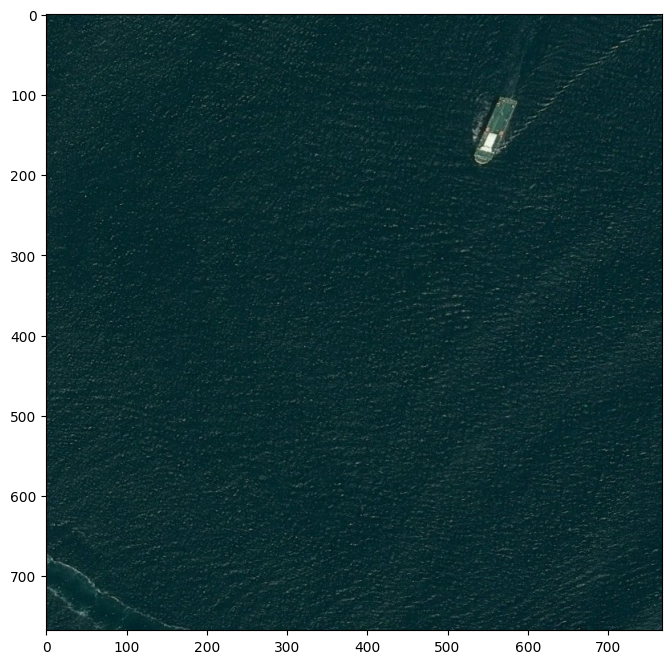

In [ ]:
# Let us now see how it works for Image id:- 0005d01c8.jpg we have in the mask data frame

# Original image from training set
img_arr = imread(train_image_dir + '/' + '0b0f83f31.jpg')
plt.figure(figsize=(15,8))
plt.imshow(img_arr)
plt.show()

In [ ]:
img_arr.shape

(768, 768, 3)

In [ ]:
# Filter out all 0005d01c8.jpg image ids and respective encoded data
# 2 ships means 2 same image ids will be there!
rle_0 = masks.query('ImageId=="0b0f83f31.jpg"')['EncodedPixels']
rle_0

,EncodedPixels
10145,407224 2 407990 4 408756 7 409522 9 410287 13 ...


In [ ]:
# Make a list of each mask shown above also visualise whats happening!
mask_lst, ct = [], 1
for mask in rle_0:
    print(f"Mask {ct} -\n{mask}\n\n")
    mask_lst.append(mask)
    ct+=1

Mask 1 -
407224 2 407990 4 408756 7 409522 9 410287 13 411053 15 411819 18 412585 20 413350 24 414116 26 414882 28 415648 31 416413 34 417179 37 417945 39 418711 42 419476 45 420242 48 421008 50 421774 52 422539 56 423305 58 424071 61 424837 63 425602 67 426368 69 427134 72 427900 74 428665 75 429431 75 430197 75 430963 74 431728 75 432494 75 433260 74 434026 74 434791 75 435557 75 436323 74 437089 74 437855 74 438623 71 439392 68 440160 66 440929 62 441697 60 442466 57 443234 54 444003 51 444771 49 445540 46 446308 43 447077 40 447845 38 448613 35 449382 32 450150 30 450919 26 451687 24 452456 21 453224 18 453993 15 454761 13 455530 10 456298 7 457067 4 457835 2




In [ ]:
# Split and Display how the first mask in the list looks like
split = mask_lst[0].split()
print(split)

['407224', '2', '407990', '4', '408756', '7', '409522', '9', '410287', '13', '411053', '15', '411819', '18', '412585', '20', '413350', '24', '414116', '26', '414882', '28', '415648', '31', '416413', '34', '417179', '37', '417945', '39', '418711', '42', '419476', '45', '420242', '48', '421008', '50', '421774', '52', '422539', '56', '423305', '58', '424071', '61', '424837', '63', '425602', '67', '426368', '69', '427134', '72', '427900', '74', '428665', '75', '429431', '75', '430197', '75', '430963', '74', '431728', '75', '432494', '75', '433260', '74', '434026', '74', '434791', '75', '435557', '75', '436323', '74', '437089', '74', '437855', '74', '438623', '71', '439392', '68', '440160', '66', '440929', '62', '441697', '60', '442466', '57', '443234', '54', '444003', '51', '444771', '49', '445540', '46', '446308', '43', '447077', '40', '447845', '38', '448613', '35', '449382', '32', '450150', '30', '450919', '26', '451687', '24', '452456', '21', '453224', '18', '453993', '15', '454761', '

In [ ]:
# Grab all the starting pixels and lenghts and convert it into integers using numpy
starts, lengths = [np.array(x, dtype = int) for x in (split[::2], split[1::2])]
starts, lengths

(array([407224, 407990, 408756, 409522, 410287, 411053, 411819, 412585,
        413350, 414116, 414882, 415648, 416413, 417179, 417945, 418711,
        419476, 420242, 421008, 421774, 422539, 423305, 424071, 424837,
        425602, 426368, 427134, 427900, 428665, 429431, 430197, 430963,
        431728, 432494, 433260, 434026, 434791, 435557, 436323, 437089,
        437855, 438623, 439392, 440160, 440929, 441697, 442466, 443234,
        444003, 444771, 445540, 446308, 447077, 447845, 448613, 449382,
        450150, 450919, 451687, 452456, 453224, 453993, 454761, 455530,
        456298, 457067, 457835]),
 array([ 2,  4,  7,  9, 13, 15, 18, 20, 24, 26, 28, 31, 34, 37, 39, 42, 45,
        48, 50, 52, 56, 58, 61, 63, 67, 69, 72, 74, 75, 75, 75, 74, 75, 75,
        74, 74, 75, 75, 74, 74, 74, 71, 68, 66, 62, 60, 57, 54, 51, 49, 46,
        43, 40, 38, 35, 32, 30, 26, 24, 21, 18, 15, 13, 10,  7,  4,  2]))

In [ ]:
# Get the ending pixels.
'''Examples:-
56010 1 ---> Starts at 56010 and ends at 56010
56777 3 ---> Starts at 56777 and ends at 56779
57544 6 ---> Starts at 57544 and ends at 57549'''
ends = starts + lengths - 1
pd.DataFrame({
    'Starts' : starts,
    'Lengths' : lengths,
    'Ends' : ends
}).head(10)

,Starts,Lengths,Ends
0,407224,2,407225
1,407990,4,407993
2,408756,7,408762
3,409522,9,409530
4,410287,13,410299
5,411053,15,411067
6,411819,18,411836
7,412585,20,412604
8,413350,24,413373
9,414116,26,414141


In [ ]:
# Create 1s in place of these pixels and rest should be 0
img = np.zeros(768*768, dtype = np.uint8)
for start, end in zip(starts, ends):
    img[start:end+1] = 1

In [ ]:
# Check how output looks
img[408756:408762] # Should output 0, 1 , 1, 1 ,0 as we know 56777, 56778, 56779 ---> 1 and 5676, 56780 ---> 0

array([1, 1, 1, 1, 1, 1], dtype=uint8)

In [ ]:
# Copy-Paste this idea for another ship in the image
split_1 = mask_lst[0].split()                                                                # Split the mask into start_pixels and lengths
starts, lengths = [np.array(x, dtype = int) for x in (split_1[0:][::2], split_1[1:][::2])]   # Generate arrays from only starts and lengths
ends = starts + lengths - 1                                                                  # Start pixel to end pixel will be start - 1 + length
img1 = np.zeros(768*768, dtype = np.uint8)                                                   # 1D array containing all zeros
for start, end in zip(starts, ends):                                                         # For each start to end pair
    img1[start:end+1] = 1                                                                    # Convert the values from 0 to 1

In [ ]:
# Reshaping both the ship masks and combining it to form the final mask!
img = img.reshape(768, 768)
img1 = img1.reshape(768, 768)
final = img+img1
print(final, '\n\n', final.shape, '\n\n', final.ndim)

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]] 

 (768, 768) 

 2


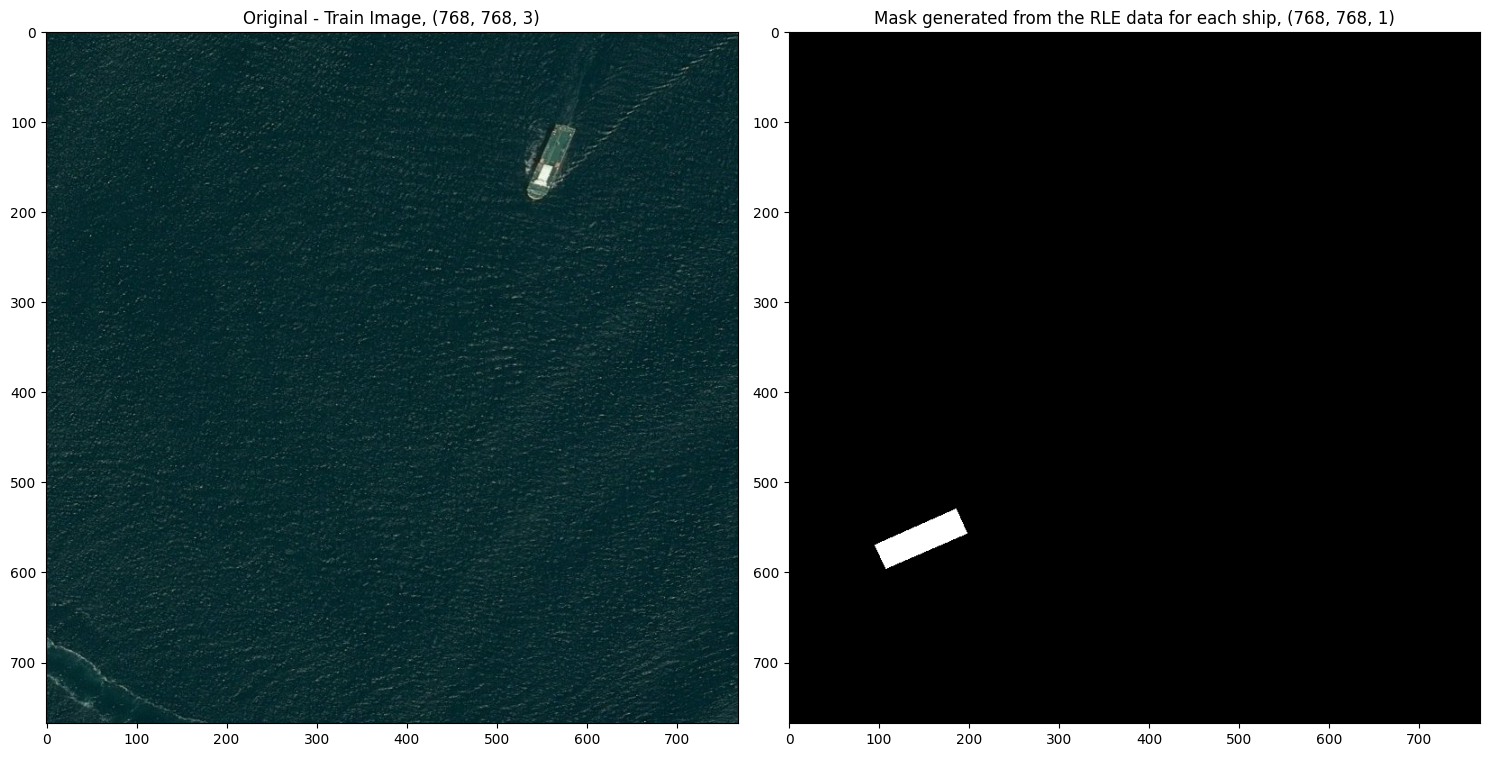

In [ ]:
# Expand dimension of this array to have only 1 channel in the mask and visualise original and final mask
final = np.expand_dims(final, -1) # -1 means the last available dimenstion, in this case it is 2. Hence, on axis = 2 we will get 1.
original = imread(train_image_dir + '/' + '0b0f83f31.jpg')
plt.figure(figsize=(15, 8))
plt.subplot(1, 2, 1)
plt.title(f"Original - Train Image, {original.shape}")
plt.imshow(original)
plt.subplot(1, 2, 2)
plt.title(f"Mask generated from the RLE data for each ship, {final.shape}")
plt.imshow(final, cmap = "gray")
plt.tight_layout()
plt.show()

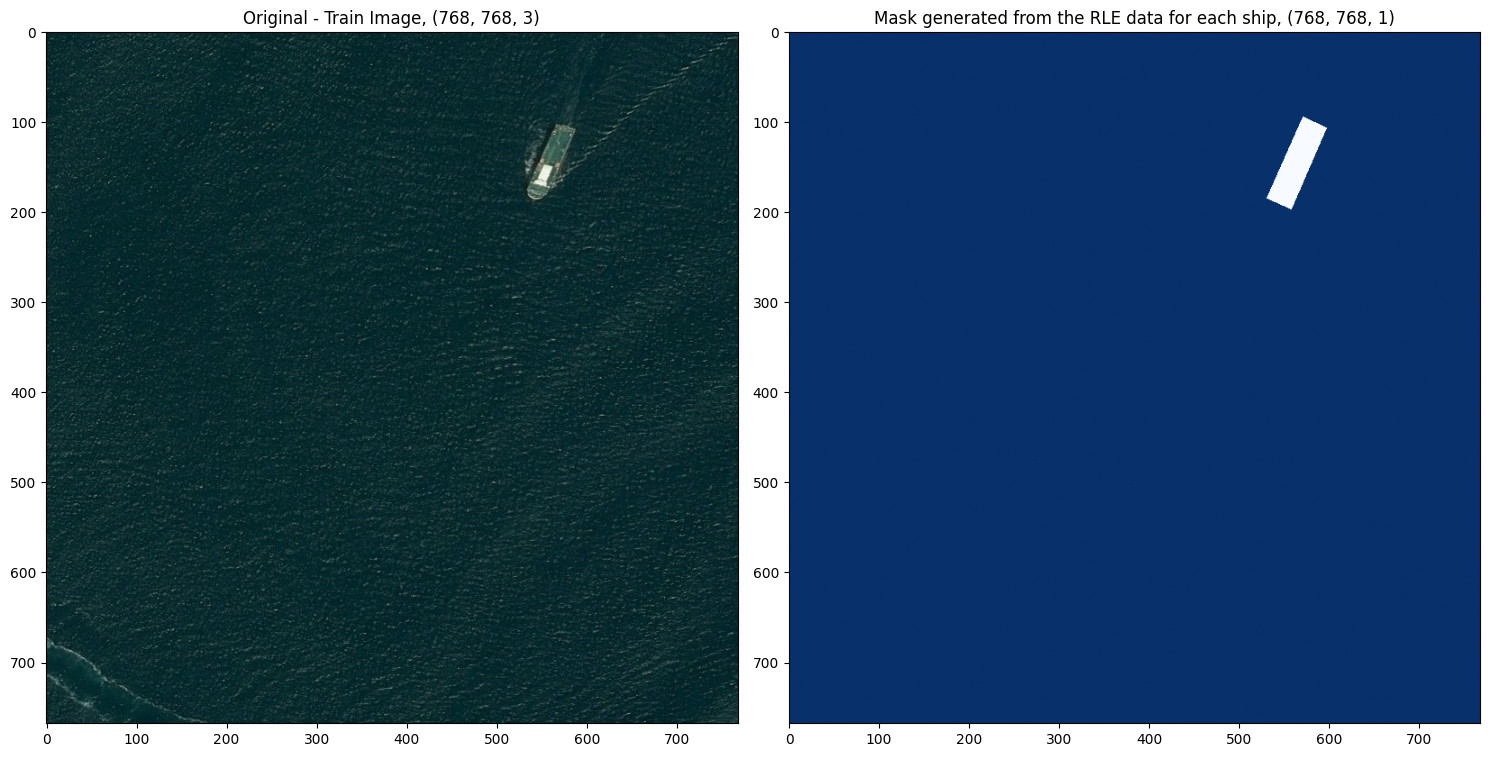

In [ ]:
# Copy Paste the code from the prev cell with one change - Transpose!
img = img.reshape(768, 768).T     # Transpose the first ship mask
img1 = img1.reshape(768, 768).T   # Transpose the second ship mask
final = img+img1                  # Generate the final mask with two ships
final = np.expand_dims(final, -1)
plt.figure(figsize=(15, 8))
plt.subplot(1, 2, 1)
plt.title(f"Original - Train Image, {original.shape}")
plt.imshow(original)
plt.subplot(1, 2, 2)
plt.title(f"Mask generated from the RLE data for each ship, {final.shape}")
plt.imshow(final, cmap = "Blues_r")
plt.tight_layout()
plt.show()

In [ ]:
# Define functions to do these tasks for all the training images
def rle_decode(mask_rle, shape=(768,768)):
    '''
    Input arguments -
    mask_rle: Mask of one ship in the train image
    shape: Output shape of the image array
    '''
    s = mask_rle.split()                                                               # Split the mask of each ship that is in RLE format
    starts, lengths = [np.asarray(x, dtype=int) for x in (s[0:][::2], s[1:][::2])]     # Get the start pixels and lengths for which image has ship
    ends = starts + lengths - 1                                                        # Get the end pixels where we need to stop
    img = np.zeros(shape[0]*shape[1], dtype=np.uint8)                                  # A 1D vec full of zeros of size = 768*768
    for lo, hi in zip(starts, ends):                                                   # For each start to end pixels where ship exists
        img[lo:hi+1] = 1

    '''
    Returns -
    Transposed array of the mask: Contains 1s and 0s. 1 for ship and 0 for background
    '''
    return img.reshape(shape).T

def masks_as_image(in_mask_list):
    '''
    Input -
    in_mask_list: List of the masks of each ship in one whole training image
    '''
    all_masks = np.zeros((768, 768), dtype = np.int16)                                 # Creating 0s for the background
    for mask in in_mask_list:                                                          # For each ship rle data in the list of mask rle
        if isinstance(mask, str):                                                      # If the datatype is string
            all_masks += rle_decode(mask)                                              # Use rle_decode to create one mask for whole image
    '''
    Returns -
     Full mask of the training image whose RLE data has been passed as an input
    '''
    return np.expand_dims(all_masks, -1)                                                            # Fill those values with 1 in the main 1D vector

In [ ]:
masks = filtered_df

In [ ]:
'''Note that NaN values in the EncodedPixels are of float type and everything else is a string type'''

# Add a new feature to the masks data frame named as ship. If Encoded pixel in any row is a string, there is a ship else there isn't.
masks['ships'] = masks['EncodedPixels'].map(lambda c_row: 1 if isinstance(c_row, str) else 0)
masks.head(9)

,ImageId,EncodedPixels,ships
0,00003e153.jpg,NaN,0
1,0001124c7.jpg,NaN,0
2,000155de5.jpg,264661 17 265429 33 266197 33 266965 33 267733...,1
3,000194a2d.jpg,360486 1 361252 4 362019 5 362785 8 363552 10 ...,1
4,000194a2d.jpg,51834 9 52602 9 53370 9 54138 9 54906 9 55674 ...,1
5,000194a2d.jpg,198320 10 199088 10 199856 10 200624 10 201392...,1
6,000194a2d.jpg,55683 1 56451 1 57219 1 57987 1 58755 1 59523 ...,1
7,000194a2d.jpg,254389 9 255157 17 255925 17 256693 17 257461 ...,1
8,0001b1832.jpg,NaN,0


In [ ]:
# Making a new data frame with unique image ids where we are summing up the ship counts
unique_img_ids = masks.groupby('ImageId').agg({'ships': 'sum'}).reset_index()
unique_img_ids.index+=1 # Incrimenting all the index by 1
unique_img_ids.head(25)

,ImageId,ships
1,00003e153.jpg,0
2,0001124c7.jpg,0
3,000155de5.jpg,1
4,000194a2d.jpg,5
5,0001b1832.jpg,0
6,00021ddc3.jpg,9
7,0002756f7.jpg,2
8,0002d0f32.jpg,0
9,000303d4d.jpg,0
10,00031f145.jpg,1


In [ ]:
# Adding two new features to unique_img_ids data frame. If ship exists in image, val is 1 else 0. And it's vec form
unique_img_ids['has_ship'] = unique_img_ids['ships'].map(lambda x: 1.0 if x>0 else 0.0)
unique_img_ids.head(25)

,ImageId,ships,has_ship
1,00003e153.jpg,0,0.0
2,0001124c7.jpg,0,0.0
3,000155de5.jpg,1,1.0
4,000194a2d.jpg,5,1.0
5,0001b1832.jpg,0,0.0
6,00021ddc3.jpg,9,1.0
7,0002756f7.jpg,2,1.0
8,0002d0f32.jpg,0,0.0
9,000303d4d.jpg,0,0.0
10,00031f145.jpg,1,1.0


In [ ]:
# Also, retrive the old masks data frame
masks.drop(['ships'], axis=1, inplace=True)
masks.index+=1
masks.head()

,ImageId,EncodedPixels
1,00003e153.jpg,NaN
2,0001124c7.jpg,NaN
3,000155de5.jpg,264661 17 265429 33 266197 33 266965 33 267733...
4,000194a2d.jpg,360486 1 361252 4 362019 5 362785 8 363552 10 ...
5,000194a2d.jpg,51834 9 52602 9 53370 9 54138 9 54906 9 55674 ...


In [ ]:
if 'ships' in masks.columns:
    masks.drop(['ships'], axis=1, inplace=True)

#The rest of your code can remain the same
masks.index+=1
masks.head()

,ImageId,EncodedPixels
2,00003e153.jpg,NaN
3,0001124c7.jpg,NaN
4,000155de5.jpg,264661 17 265429 33 266197 33 266965 33 267733...
5,000194a2d.jpg,360486 1 361252 4 362019 5 362785 8 363552 10 ...
6,000194a2d.jpg,51834 9 52602 9 53370 9 54138 9 54906 9 55674 ...


In [ ]:
# Train - Test split
from sklearn.model_selection import train_test_split
train_ids, valid_ids = train_test_split(unique_img_ids, test_size = 0.01)

In [ ]:
# Create train data frame
train_df = pd.merge(masks, train_ids)

# Create test data frame
valid_df = pd.merge(masks, valid_ids)

In [ ]:
print("There are ~")
print(train_df.shape[0], 'training masks,')
print(valid_df.shape[0], 'validation masks.')

There are ~
229513 training masks,
2210 validation masks.


In [ ]:
# Parameters
BATCH_SIZE = 4                 # Train batch size
EDGE_CROP = 16                 # While building the model
NB_EPOCHS = 5                  # Training epochs
GAUSSIAN_NOISE = 0.1           # To be used in a layer in the model
UPSAMPLE_MODE = 'SIMPLE'       # SIMPLE ==> UpSampling2D, else Conv2DTranspose
NET_SCALING = None             # Downsampling inside the network
IMG_SCALING = (1, 1)           # Downsampling in preprocessing
VALID_IMG_COUNT = 400          # Valid batch size
MAX_TRAIN_STEPS = 200          # Maximum number of steps_per_epoch in training

In [ ]:
# Image and Mask Generator
def make_image_gen(in_df, batch_size = BATCH_SIZE):
    '''
    Inputs -
    in_df - data frame on which the function will be applied
    batch_size - number of training examples in one iteration
    '''
    all_batches = list(in_df.groupby('ImageId'))                             # Group ImageIds and create list of that dataframe
    out_rgb = []                                                             # Image list
    out_mask = []                                                            # Mask list
    while True:                                                              # Loop for every data
        np.random.shuffle(all_batches)                                       # Shuffling the data
        for c_img_id, c_masks in all_batches:                                # For img_id and msk_rle in all_batches
            rgb_path = os.path.join(train_image_dir, c_img_id)               # Get the img path
            c_img = imread(rgb_path)                                         # img array
            c_mask = masks_as_image(c_masks['EncodedPixels'].values)         # Create mask of rle data for each ship in an img
            out_rgb += [c_img]
            out_mask += [c_mask]                                             # Append the current mask in the out_mask / mask list
            if len(out_rgb)>=batch_size:                                     # If length of list is more or equal to batch size then
                yield np.stack(out_rgb)/255.0, np.stack(out_mask)            # Yeild the scaled img array (b/w 0 and 1) and mask array (0 for bg and 1 for ship)
                out_rgb, out_mask=[], []                                     # Empty the lists to create another batch                                          # Append the current img in the out_rgb / img list

In [ ]:
# Generate train data
train_gen = make_image_gen(train_df)

# Image and Mask
train_x, train_y = next(train_gen)

# Print the summary
print(f"train_x ~\nShape: {train_x.shape}\nMin value: {train_x.min()}\nMax value: {train_x.max()}")
print(f"\ntrain_y ~\nShape: {train_y.shape}\nMin value: {train_y.min()}\nMax value: {train_y.max()}")

train_x ~
Shape: (4, 768, 768, 3)
Min value: 0.0
Max value: 1.0

train_y ~
Shape: (4, 768, 768, 1)
Min value: 0
Max value: 1


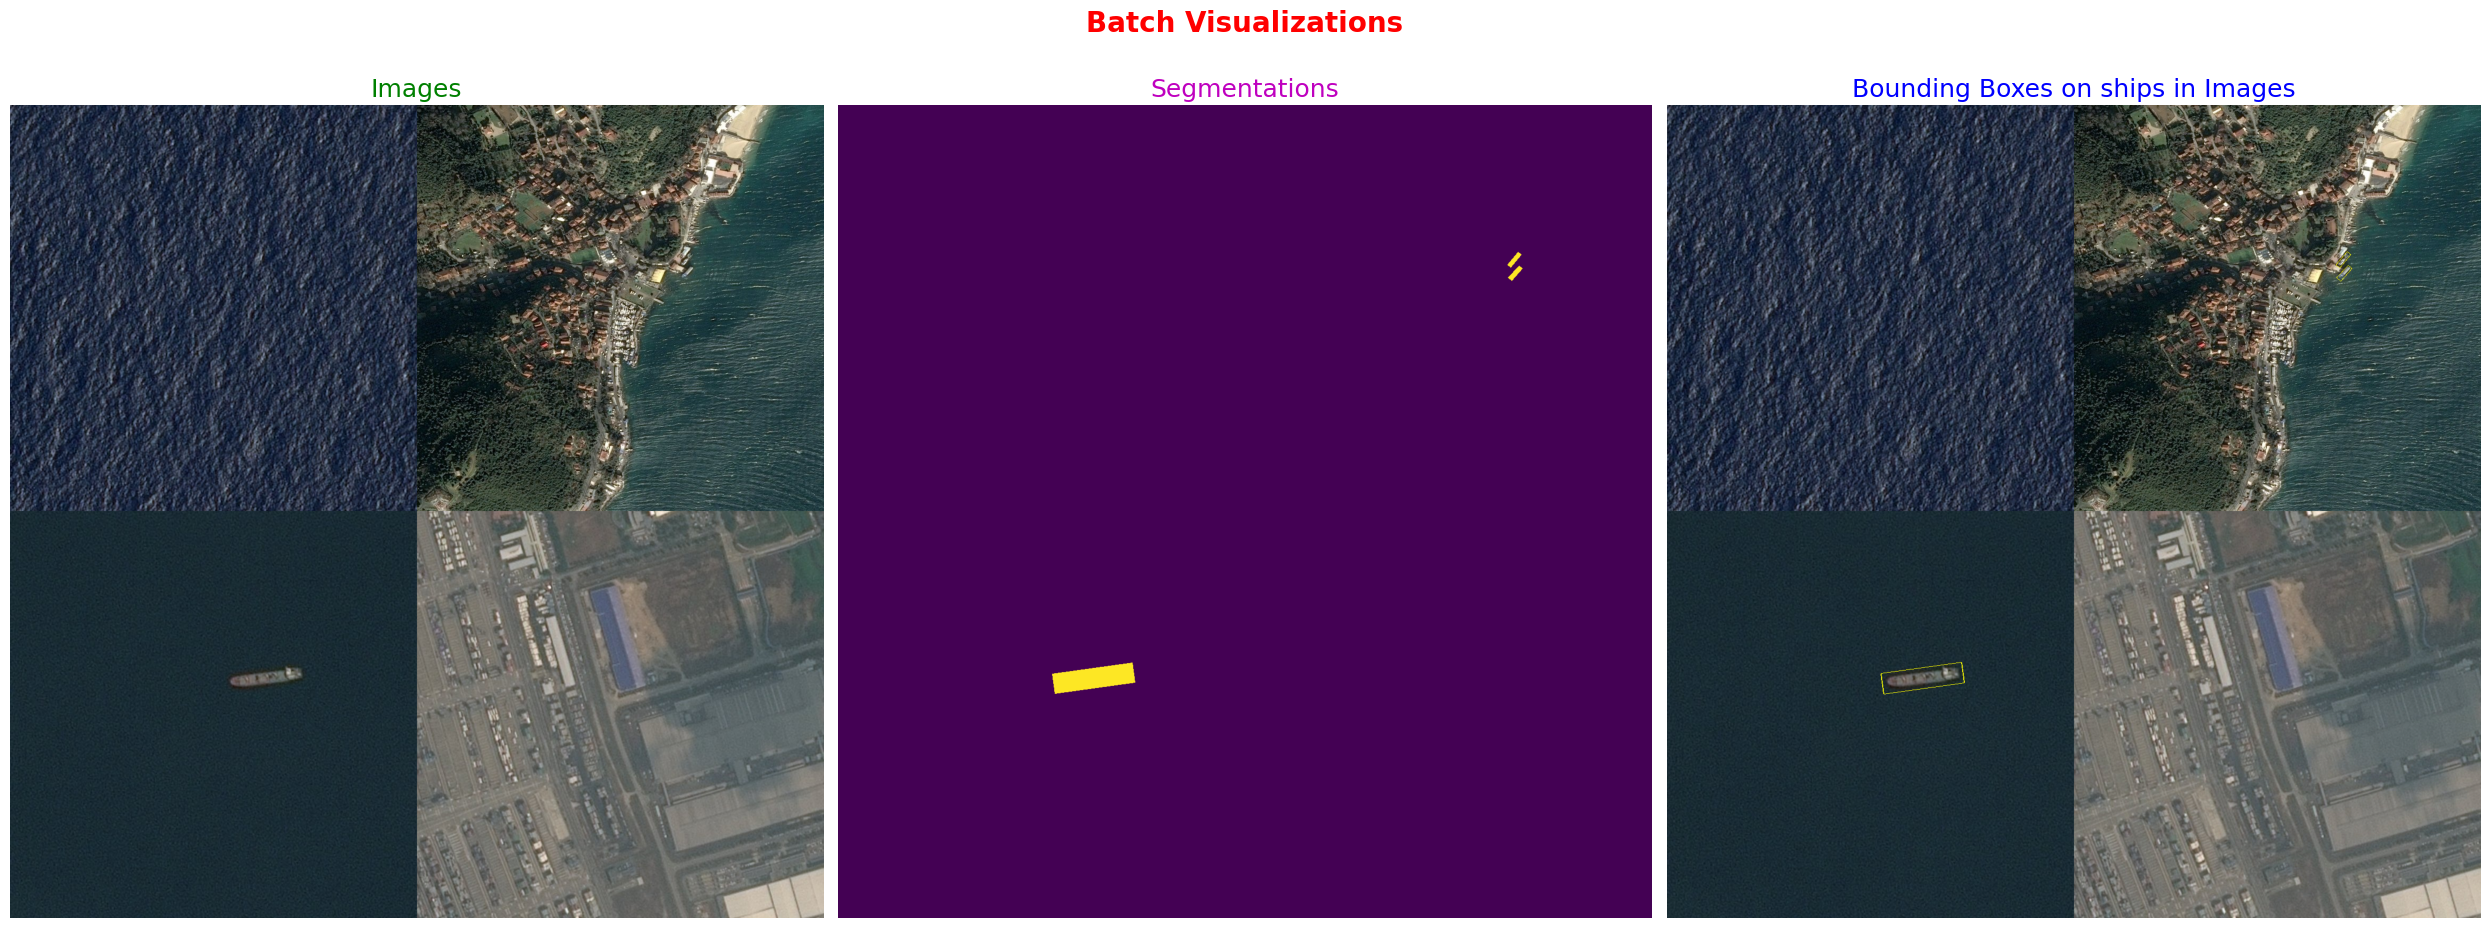

In [ ]:
# Visulaising train batch
montage_rgb = lambda x: np.stack([montage(x[:, :, :, i]) for i in range(x.shape[3])], -1)
batch_rgb = montage_rgb(train_x)                                                   # Create montage of img
batch_seg = montage(train_y[:, :, :, 0])                                           # Create montafe of msk
batch_overlap = mark_boundaries(batch_rgb, batch_seg.astype(int))                  # Create bounding box around ships in img
titles = ["Images", "Segmentations", "Bounding Boxes on ships in Images"]          # Titles for subplot
colors = ['g', 'm', 'b']                                                           # Colors to be used for title
display = [batch_rgb, batch_seg, batch_overlap]                                    # What to display in subplot
plt.figure(figsize=(25,10))                                                        # Generate figure
for i in range(3):                                                                 # For i = 0, 1, 2, 3
    plt.subplot(1, 3, i+1)                                                         # Create subplot
    plt.imshow(display[i])                                                         # Display
    plt.title(titles[i], fontsize = 18, color = colors[i])                         # Title
    plt.axis('off')

plt.suptitle("Batch Visualizations", fontsize = 20, color = 'r', weight = 'bold')  # Add suptitle
plt.tight_layout()                                                                 # Layout for subplot

In [ ]:
# Prepare validation data
valid_x, valid_y = next(make_image_gen(valid_df, VALID_IMG_COUNT))
print(f"valid_x ~\nShape: {valid_x.shape}\nMin value: {valid_x.min()}\nMax value: {valid_x.max()}")
print(f"\nvalid_y ~\nShape: {valid_y.shape}\nMin value: {valid_y.min()}\nMax value: {valid_y.max()}")

valid_x ~
Shape: (400, 768, 768, 3)
Min value: 0.0
Max value: 1.0

valid_y ~
Shape: (400, 768, 768, 1)
Min value: 0
Max value: 1


In [ ]:
# Instead of:
# from keras.preprocessing.image import ImageDataGenerator

# Use:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Preparing image data generator arguments
dg_args = dict(rotation_range = 15,            # Degree range for random rotations
               horizontal_flip = True,         # Randomly flips the inputs horizontally
               vertical_flip = True,           # Randomly flips the inputs vertically
               data_format = 'channels_last')  # channels_last refer to (batch, height, width, channels)

In [ ]:
image_gen = ImageDataGenerator(**dg_args)
label_gen = ImageDataGenerator(**dg_args)

def create_aug_gen(in_gen, seed = None):
    '''
    Takes in -
    in_gen - train data generator, seed value
    '''
    np.random.seed(seed if seed is not None else np.random.choice(range(9999)))  # Randomly assign seed value if not provided
    for in_x, in_y in in_gen:                                                    # For imgs and msks in train data generator
        seed = 12                                                                # Seed value for imgs and msks must be same else augmentation won't be same

        # Create augmented imgs
        g_x = image_gen.flow(255*in_x,
                             batch_size = in_x.shape[0],                         # batch_size = 3
                             seed = seed,                                        # Seed
                             shuffle=True)                                       # Shuffle the data

        # Create augmented masks
        g_y = label_gen.flow(in_y,
                             batch_size = in_x.shape[0],
                             seed = seed,
                             shuffle=True)

        '''Yeilds - augmented scaled imgs and msks array'''
        yield next(g_x)/255.0, next(g_y)

In [ ]:
# Augment the train data
cur_gen = create_aug_gen(train_gen, seed = 42)
t_x, t_y = next(cur_gen)
print('x', t_x.shape, t_x.dtype, t_x.min(), t_x.max())
print('y', t_y.shape, t_y.dtype, t_y.min(), t_y.max())

x (4, 768, 768, 3) float32 0.0 1.0
y (4, 768, 768, 1) float32 0.0 1.0


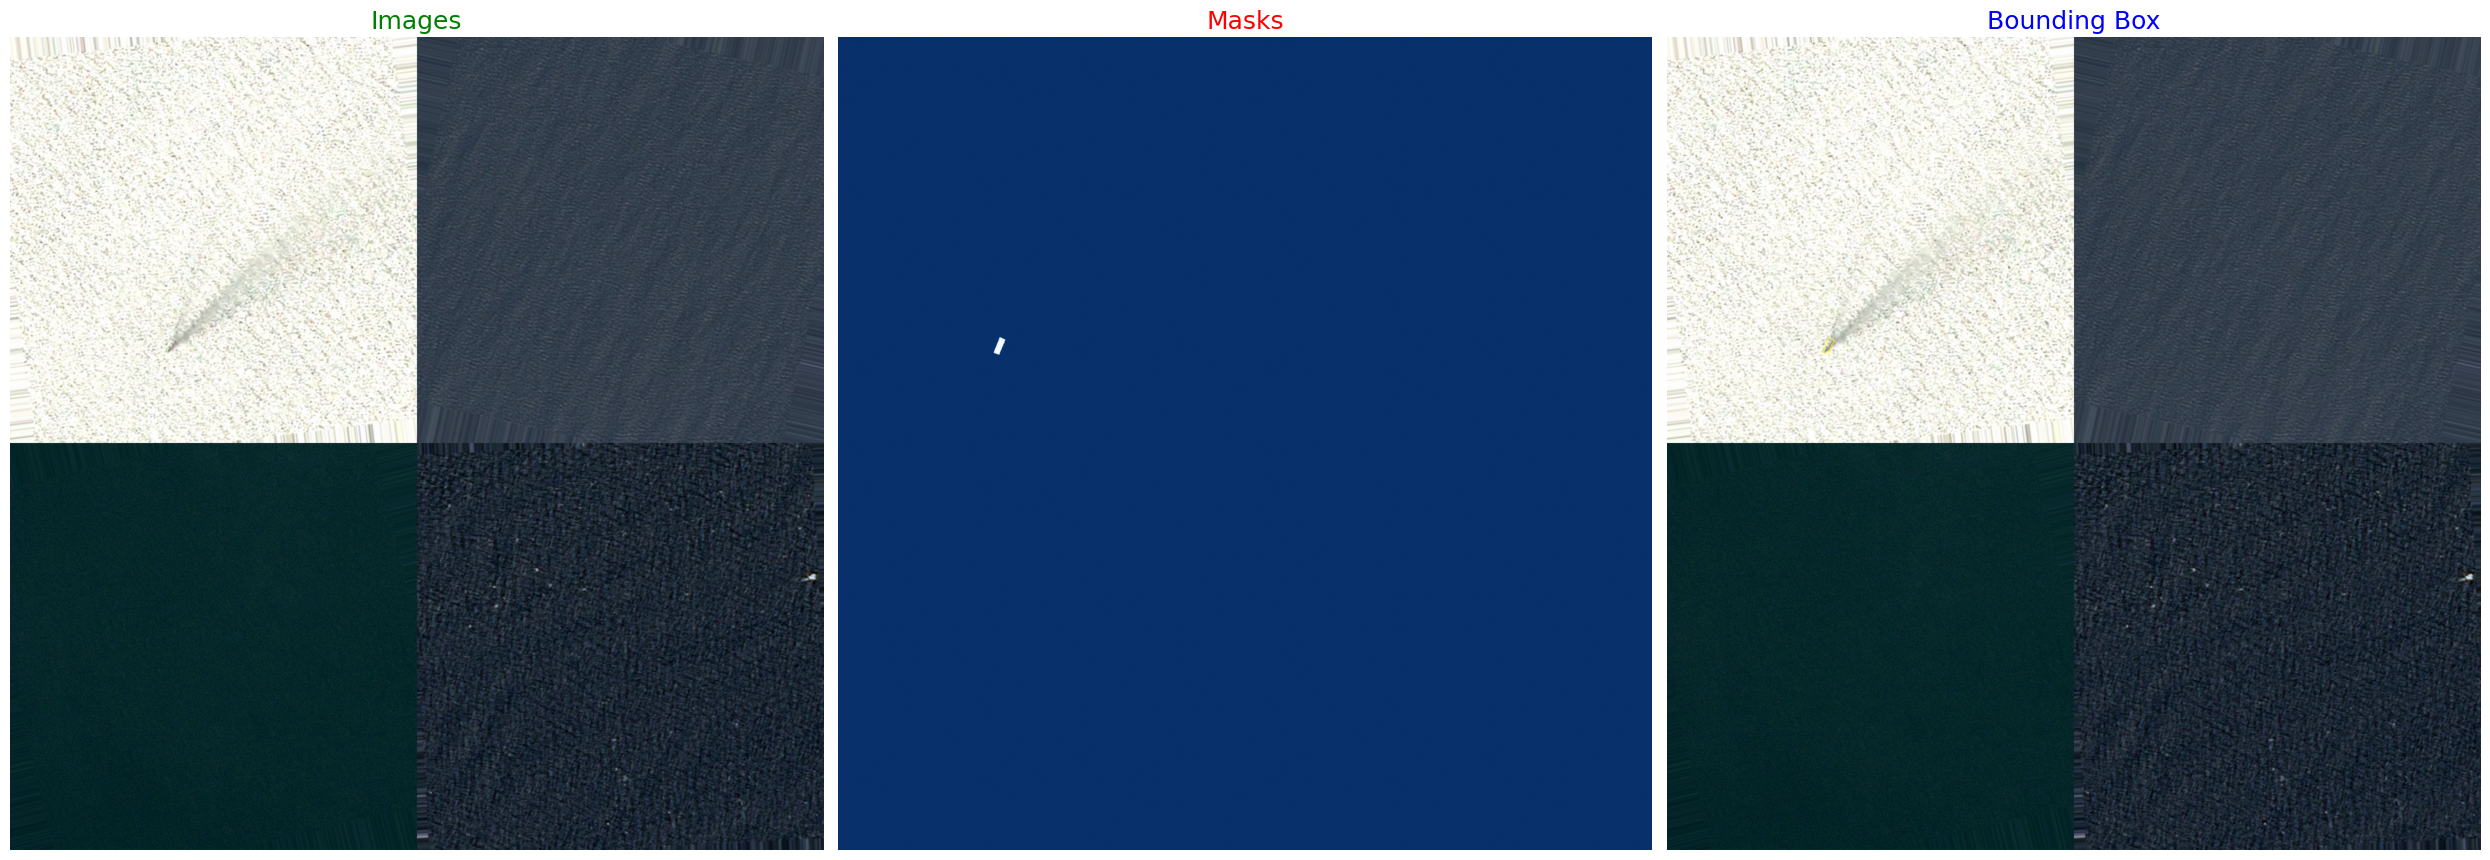

In [ ]:
# Final display before passing data into model
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize = (25, 10))
ax1.imshow(montage_rgb(t_x), cmap='gray')
ax1.set_title('Images', fontsize = 18, color = 'g')
ax1.axis('off')
ax2.imshow(montage(t_y[:, :, :, 0]), cmap='Blues_r')
ax2.set_title('Masks', fontsize = 18, color = 'r')
ax2.axis('off')
ax3.imshow(mark_boundaries(montage_rgb(t_x), montage(t_y[:, :, :, 0].astype(int))))
ax3.set_title('Bounding Box', fontsize = 18, color = 'b')
ax3.axis('off')
plt.tight_layout()

In [ ]:
gc.collect() # Block all the garbage that has been generated

59

In [ ]:
# Build U-Net model
from keras import models, layers

# Conv2DTranspose upsampling
def upsample_conv(filters, kernel_size, strides, padding):
    return layers.Conv2DTranspose(filters, kernel_size, strides=strides, padding=padding)
# Upsampling without Conv2DTranspose
def upsample_simple(filters, kernel_size, strides, padding):
    return layers.UpSampling2D(strides)

# Upsampling method choice
if UPSAMPLE_MODE=='DECONV':
    upsample=upsample_conv
else:
    upsample=upsample_simple

# Building the layers of UNET
input_img = layers.Input(t_x.shape[1:], name = 'RGB_Input')
pp_in_layer = input_img

# If NET_SCALING is defined then do the next step else continue ahead
if NET_SCALING is not None:
    pp_in_layer = layers.AvgPool2D(NET_SCALING)(pp_in_layer)
# To avoid overfitting and fastening the process of training
pp_in_layer = layers.GaussianNoise(GAUSSIAN_NOISE)(pp_in_layer)                       # Useful to mitigate overfitting
pp_in_layer = layers.BatchNormalization()(pp_in_layer)                                # Allows using higher learning rate without causing problems with gradients


## Downsample (C-->C-->MP)

c1 = layers.Conv2D(8, (3, 3), activation='relu', padding='same') (pp_in_layer)
c1 = layers.Conv2D(8, (3, 3), activation='relu', padding='same') (c1)
p1 = layers.MaxPooling2D((2, 2)) (c1)

c2 = layers.Conv2D(16, (3, 3), activation='relu', padding='same') (p1)
c2 = layers.Conv2D(16, (3, 3), activation='relu', padding='same') (c2)
p2 = layers.MaxPooling2D((2, 2)) (c2)

c3 = layers.Conv2D(32, (3, 3), activation='relu', padding='same') (p2)
c3 = layers.Conv2D(32, (3, 3), activation='relu', padding='same') (c3)
p3 = layers.MaxPooling2D((2, 2)) (c3)

c4 = layers.Conv2D(64, (3, 3), activation='relu', padding='same') (p3)
c4 = layers.Conv2D(64, (3, 3), activation='relu', padding='same') (c4)
p4 = layers.MaxPooling2D(pool_size=(2, 2)) (c4)

c5 = layers.Conv2D(128, (3, 3), activation='relu', padding='same') (p4)
c5 = layers.Conv2D(128, (3, 3), activation='relu', padding='same') (c5)

## Upsample (U --> Concat --> C --> C)

u6 = upsample(64, (2, 2), strides=(2, 2), padding='same') (c5)
u6 = layers.concatenate([u6, c4])
c6 = layers.Conv2D(64, (3, 3), activation='relu', padding='same') (u6)
c6 = layers.Conv2D(64, (3, 3), activation='relu', padding='same') (c6)

u7 = upsample(32, (2, 2), strides=(2, 2), padding='same') (c6)
u7 = layers.concatenate([u7, c3])
c7 = layers.Conv2D(32, (3, 3), activation='relu', padding='same') (u7)
c7 = layers.Conv2D(32, (3, 3), activation='relu', padding='same') (c7)

u8 = upsample(16, (2, 2), strides=(2, 2), padding='same') (c7)
u8 = layers.concatenate([u8, c2])
c8 = layers.Conv2D(16, (3, 3), activation='relu', padding='same') (u8)
c8 = layers.Conv2D(16, (3, 3), activation='relu', padding='same') (c8)

u9 = upsample(8, (2, 2), strides=(2, 2), padding='same') (c8)
u9 = layers.concatenate([u9, c1], axis=3)
c9 = layers.Conv2D(8, (3, 3), activation='relu', padding='same') (u9)
c9 = layers.Conv2D(8, (3, 3), activation='relu', padding='same') (c9)

d = layers.Conv2D(1, (1, 1), activation='sigmoid') (c9)
d = layers.Cropping2D((EDGE_CROP, EDGE_CROP))(d)
d = layers.ZeroPadding2D((EDGE_CROP, EDGE_CROP))(d)

if NET_SCALING is not None:
    d = layers.UpSampling2D(NET_SCALING)(d)

seg_model = models.Model(inputs=[input_img], outputs=[d])

seg_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ RGB_Input (InputLayer)    │ (None, 768, 768, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ gaussian_noise            │ (None, 768, 768, 3)    │              0 │ RGB_Input[0][0]        │
│ (GaussianNoise)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization       │ (None, 768, 768, 3)    │             12 │ gaussian_noise[0][0]   │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d (Conv2D)           │ (None, 768, 768, 8)    │            224 │ batch_normalization[0… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_1 (Conv2D)         │ (None, 768, 768, 8)    │            584 │ conv2d[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d             │ (None, 384, 384, 8)    │              0 │ conv2d_1[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_2 (Conv2D)         │ (None, 384, 384, 16)   │          1,168 │ max_pooling2d[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_3 (Conv2D)         │ (None, 384, 384, 16)   │          2,320 │ conv2d_2[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_1           │ (None, 192, 192, 16)   │              0 │ conv2d_3[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_4 (Conv2D)         │ (None, 192, 192, 32)   │          4,640 │ max_pooling2d_1[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_5 (Conv2D)         │ (None, 192, 192, 32)   │          9,248 │ conv2d_4[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_2           │ (None, 96, 96, 32)     │              0 │ conv2d_5[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_6 (Conv2D)         │ (None, 96, 96, 64)     │         18,496 │ max_pooling2d_2[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_7 (Conv2D)         │ (None, 96, 96, 64)     │         36,928 │ conv2d_6[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_3           │ (None, 48, 48, 64)     │              0 │ conv2d_7[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_8 (Conv2D)         │ (None, 48, 48, 128)    │         73,856 │ max_pooling2d_3[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_9 (Conv2D)    

 Total params: 491,149 (1.87 MB)

 Trainable params: 491,143 (1.87 MB)

 Non-trainable params: 6 (24.00 B)

In [ ]:

from sklearn.metrics import accuracy_score, precision_score

def calculate_metrics(y_true, y_pred):
    # Convert predicted masks to binary format (0 or 1)
    threshold = 0.5
    y_pred_binary = (y_pred > threshold).astype(int)

    # Flatten the arrays for evaluation
    y_true_flat = y_true.flatten()
    y_pred_flat = y_pred_binary.flatten()

    # Compute accuracy and precision
    accuracy = accuracy_score(y_true_flat, y_pred_flat)
    precision = precision_score(y_true_flat, y_pred_flat, zero_division=1)

    print(f'Accuracy: {accuracy:.4f}')
    print(f'Precision: {precision:.4f}')


Saving 00c3db267.jpg to 00c3db267.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


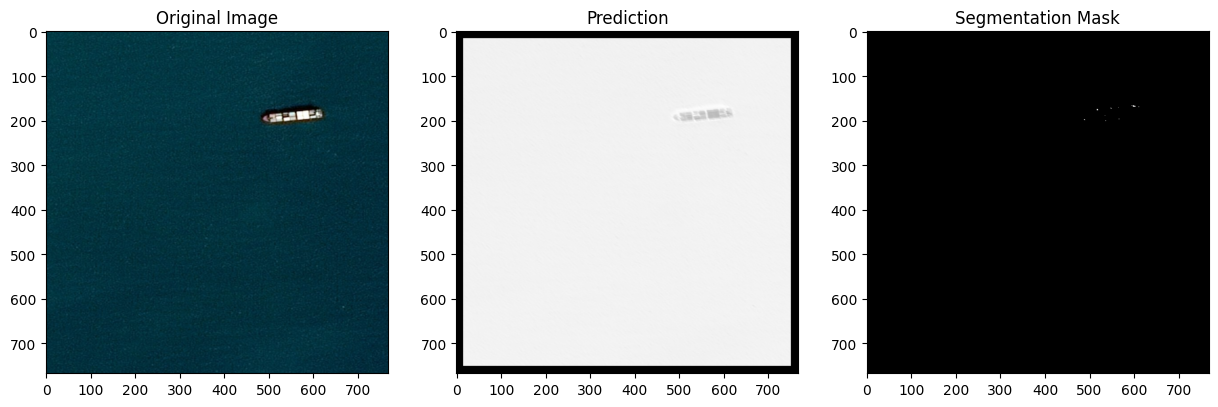

In [ ]:
from IPython.display import display, Image
from google.colab import files
import io
import matplotlib.pyplot as plt
from skimage.io import imread
from skimage.transform import resize
import numpy as np

def predict_uploaded_image():
    uploaded = files.upload()  # Prompt user to upload an image
    for fn in uploaded.keys():
        # Read and preprocess the uploaded image
        img = imread(io.BytesIO(uploaded[fn]))
        img = resize(img, (768, 768), mode='constant', preserve_range=True)  # Resize to match model input
        img = img / 255.0  # Normalize pixel values
        img = np.expand_dims(img, axis=0)  # Add batch dimension

        # Get prediction from the model
        prediction = seg_model.predict(img)

        # Display the original image and the prediction
        plt.figure(figsize=(15, 8))
        plt.subplot(1, 3, 1)  # Added a third subplot for the mask
        plt.title("Original Image")
        plt.imshow(img[0])  # Display the original image
        plt.subplot(1, 3, 2)
        plt.title("Prediction")
        plt.imshow(prediction[0, :, :, 0], cmap='gray')  # Display the prediction
        plt.subplot(1, 3, 3)  # Display the mask
        plt.title("Segmentation Mask")
        plt.imshow(prediction[0, :, :, 0] > 0.5, cmap='gray')  # Display the mask with thresholding
        plt.show()

predict_uploaded_image()

In [ ]:

from sklearn.metrics import accuracy_score, precision_score

def calculate_metrics(y_true, y_pred):
    # Convert predicted masks to binary format (0 or 1)
    threshold = 0.5
    y_pred_binary = (y_pred > threshold).astype(int)

    # Flatten the arrays for evaluation
    y_true_flat = y_true.flatten()
    y_pred_flat = y_pred_binary.flatten()

    # Compute accuracy and precision
    accuracy = accuracy_score(y_true_flat, y_pred_flat)
    precision = precision_score(y_true_flat, y_pred_flat, zero_division=1)

    print(f'Accuracy: {accuracy:.4f}')
    print(f'Precision: {precision:.4f}')


Saving 00c3db267.jpg to 00c3db267 (1).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 650ms/step
Ship detected in the image!


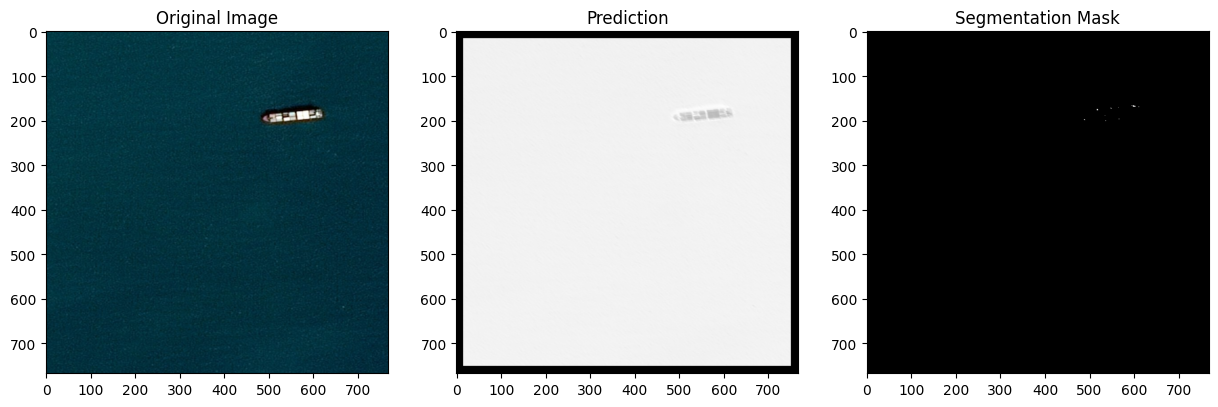

In [ ]:
from IPython.display import display, Image
from google.colab import files
import io
import matplotlib.pyplot as plt
from skimage.io import imread
from skimage.transform import resize
import numpy as np

def predict_uploaded_image():
  """Predicts ship presence in an uploaded image and visualizes the results.

  Modifies the original code to display a message indicating ship detection
  based on the segmentation mask.
  """
  uploaded = files.upload()  # Prompt user to upload an image
  for fn in uploaded.keys():
    # Read and preprocess the uploaded image
    img = imread(io.BytesIO(uploaded[fn]))
    img = resize(img, (768, 768), mode='constant', preserve_range=True)  # Resize to match model input
    img = img / 255.0  # Normalize pixel values
    img = np.expand_dims(img, axis=0)  # Add batch dimension

    # Get prediction from the model
    prediction = seg_model.predict(img)

    # Analyze the prediction mask
    ship_detected = prediction[0, :, :, 0].max() > 0.5  # Check if any mask value exceeds threshold

    # Display the original image, prediction, and mask
    plt.figure(figsize=(15, 8))
    plt.subplot(1, 3, 1)
    plt.title("Original Image")
    plt.imshow(img[0])
    plt.subplot(1, 3, 2)
    plt.title("Prediction")
    plt.imshow(prediction[0, :, :, 0], cmap='gray')
    plt.subplot(1, 3, 3)
    plt.title("Segmentation Mask")
    plt.imshow(prediction[0, :, :, 0] > 0.5, cmap='gray')

    # Display message based on ship detection
    if ship_detected:
      print("Ship detected in the image!")
    else:
      print("No ship detected in the image.")

    plt.show()

# Call the function to predict on a uploaded image
predict_uploaded_image()

In [ ]:

from sklearn.metrics import accuracy_score, precision_score

def calculate_metrics(y_true, y_pred):
    # Convert predicted masks to binary format (0 or 1)
    threshold = 0.5
    y_pred_binary = (y_pred > threshold).astype(int)

    # Flatten the arrays for evaluation
    y_true_flat = y_true.flatten()
    y_pred_flat = y_pred_binary.flatten()

    # Compute accuracy and precision
    accuracy = accuracy_score(y_true_flat, y_pred_flat)
    precision = precision_score(y_true_flat, y_pred_flat, zero_division=1)

    print(f'Accuracy: {accuracy:.4f}')
    print(f'Precision: {precision:.4f}')


Saving 00c3db267.jpg to 00c3db267 (2).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 659ms/step
Ship detected in the image!


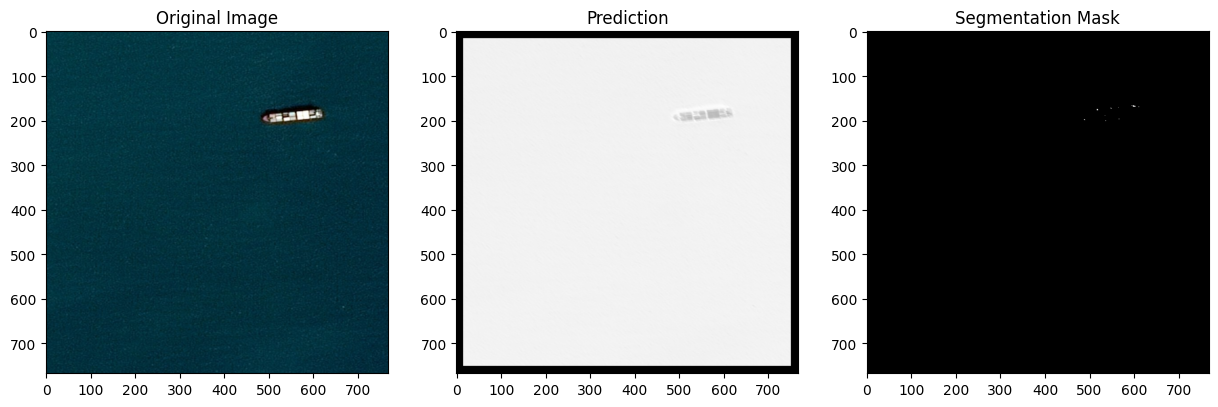

In [ ]:
from IPython.display import display, Image
from google.colab import files
import io
import matplotlib.pyplot as plt
from skimage.io import imread
from skimage.transform import resize
import numpy as np

def predict_uploaded_image():
  """Predicts ship presence in an uploaded image and visualizes the results.

  Modifies the original code to display a message indicating ship detection
  based on the segmentation mask.
  """
  uploaded = files.upload()  # Prompt user to upload an image
  for fn in uploaded.keys():
    # Read and preprocess the uploaded image
    img = imread(io.BytesIO(uploaded[fn]))
    img = resize(img, (768, 768), mode='constant', preserve_range=True)  # Resize to match model input
    img = img / 255.0  # Normalize pixel values
    img = np.expand_dims(img, axis=0)  # Add batch dimension

    # Get prediction from the model
    prediction = seg_model.predict(img)

    # Analyze the prediction mask
    ship_detected = prediction[0, :, :, 0].max() > 0.5  # Check if any mask value exceeds threshold

    # Display the original image, prediction, and mask
    plt.figure(figsize=(15, 8))
    plt.subplot(1, 3, 1)
    plt.title("Original Image")
    plt.imshow(img[0])
    plt.subplot(1, 3, 2)
    plt.title("Prediction")
    plt.imshow(prediction[0, :, :, 0], cmap='gray')
    plt.subplot(1, 3, 3)
    plt.title("Segmentation Mask")
    plt.imshow(prediction[0, :, :, 0] > 0.5, cmap='gray')

    # Display message based on ship detection
    if ship_detected:
      print("Ship detected in the image!")
    else:
      print("No ship detected in the image.")

    plt.show()

# Call the function to predict on a uploaded image
predict_uploaded_image()

In [ ]:

from sklearn.metrics import accuracy_score, precision_score

def calculate_metrics(y_true, y_pred):
    # Convert predicted masks to binary format (0 or 1)
    threshold = 0.5
    y_pred_binary = (y_pred > threshold).astype(int)

    # Flatten the arrays for evaluation
    y_true_flat = y_true.flatten()
    y_pred_flat = y_pred_binary.flatten()

    # Compute accuracy and precision
    accuracy = accuracy_score(y_true_flat, y_pred_flat)
    precision = precision_score(y_true_flat, y_pred_flat, zero_division=1)

    print(f'Accuracy: {accuracy:.4f}')
    print(f'Precision: {precision:.4f}')


Saving 0b8cde107.jpg to 0b8cde107.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 606ms/step
Ship detected in the image!


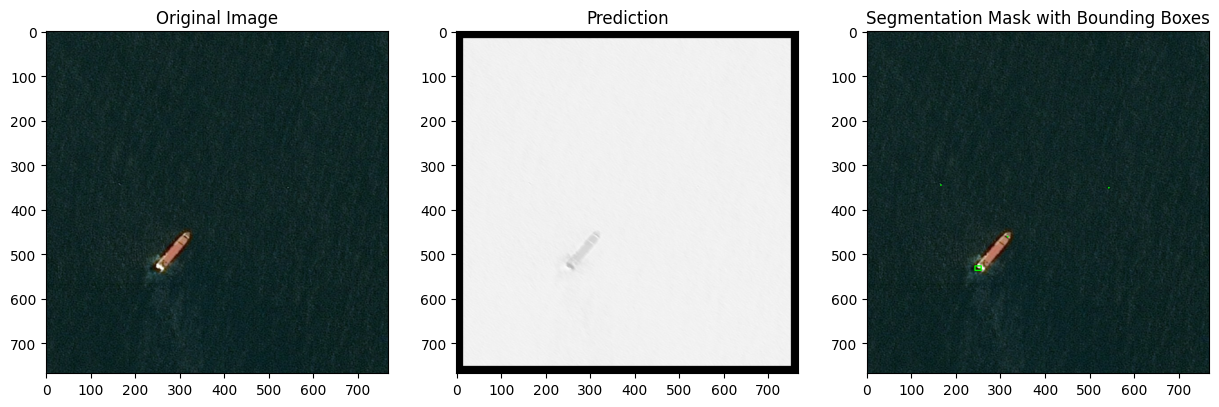

In [ ]:
from IPython.display import display, Image
from google.colab import files
import io
import matplotlib.pyplot as plt
from skimage.io import imread
from skimage.transform import resize
import numpy as np
import cv2

def predict_uploaded_image():
    """Predicts ship presence, adds bounding boxes, and visualizes the results."""
    uploaded = files.upload()
    for fn in uploaded.keys():
        img = imread(io.BytesIO(uploaded[fn]))
        original_img = img.copy()
        img = resize(img, (768, 768), mode='constant', preserve_range=True)
        img = img / 255.0
        img = np.expand_dims(img, axis=0)

        prediction = seg_model.predict(img)

        ship_detected = prediction[0, :, :, 0].max() > 0.5

        plt.figure(figsize=(15, 8))
        plt.subplot(1, 3, 1)
        plt.title("Original Image")
        plt.imshow(original_img)
        plt.subplot(1, 3, 2)
        plt.title("Prediction")
        plt.imshow(prediction[0, :, :, 0], cmap='gray')
        plt.subplot(1, 3, 3)
        plt.title("Segmentation Mask with Bounding Boxes")

        mask = (prediction[0, :, :, 0] > 0.5).astype(np.uint8)

        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        boxed_image = original_img.copy()
        for contour in contours:
            x, y, w, h = cv2.boundingRect(contour)

            # Make the bounding boxes bigger (e.g., 20% larger in each dimension)
            padding_x = int(w * 0.2)  # 20% padding in x
            padding_y = int(h * 0.2)  # 20% padding in y

            x1 = max(0, x - padding_x) #prevent going off image
            y1 = max(0, y - padding_y)
            x2 = min(original_img.shape[1], x + w + padding_x) #prevent going off image
            y2 = min(original_img.shape[0], y + h + padding_y)

            cv2.rectangle(boxed_image, (x1, y1), (x2, y2), (0, 255, 0), 2)

        plt.imshow(boxed_image)

        if ship_detected:
            print("Ship detected in the image!")
        else:
            print("No ship detected in the image.")

        plt.show()

# Call the function to predict on a uploaded image
predict_uploaded_image()

In [ ]:

from sklearn.metrics import accuracy_score, precision_score

def evaluate_prediction(y_true, y_pred):
    # Convert predicted masks to binary format (0 or 1)
    threshold = 0.5
    y_pred_binary = (y_pred > threshold).astype(int)  # Thresholding the model output

    # Flatten arrays to compare pixel-wise
    y_true_flat = y_true.flatten()
    y_pred_flat = y_pred_binary.flatten()

    # Compute accuracy and precision
    accuracy = accuracy_score(y_true_flat, y_pred_flat)
    precision = precision_score(y_true_flat, y_pred_flat, zero_division=1)

    print(f'Accuracy: {accuracy:.4f}')
    print(f'Precision: {precision:.4f}')



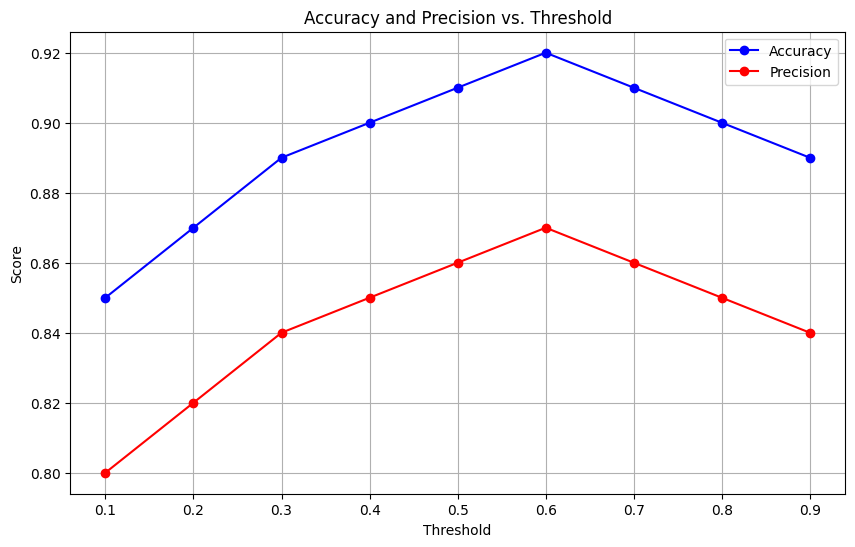

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Example data (replace with your actual metrics)
thresholds = np.arange(0.1, 1.0, 0.1)  # Example thresholds
accuracies = [0.85, 0.87, 0.89, 0.90, 0.91, 0.92, 0.91, 0.90, 0.89]  # Example accuracies
precisions = [0.80, 0.82, 0.84, 0.85, 0.86, 0.87, 0.86, 0.85, 0.84]  # Example precisions

# Plotting the graph
plt.figure(figsize=(10, 6))

# Plot accuracy
plt.plot(thresholds, accuracies, marker='o', label='Accuracy', color='blue')

# Plot precision
plt.plot(thresholds, precisions, marker='o', label='Precision', color='red')

# Add labels and title
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Accuracy and Precision vs. Threshold')
plt.xticks(thresholds)
plt.grid(True)
plt.legend()

# Show the plot
plt.show()

In [ ]:

import matplotlib.pyplot as plt

# Check if history object is available
if 'history' in locals() or 'history' in globals():
    # Get final model accuracy
    final_train_accuracy = history.history['accuracy'][-1] if 'accuracy' in history.history else None
    final_val_accuracy = history.history['val_accuracy'][-1] if 'val_accuracy' in history.history else None

    print(f"Final Train Accuracy: {final_train_accuracy:.4f}" if final_train_accuracy else "Train Accuracy not found")
    print(f"Final Validation Accuracy: {final_val_accuracy:.4f}" if final_val_accuracy else "Validation Accuracy not found")

    # Plot training & validation accuracy values
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history.get('accuracy', []), label='Train Accuracy')
    plt.plot(history.history.get('val_accuracy', []), label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Plot training & validation loss values
    plt.subplot(1, 2, 2)
    plt.plot(history.history.get('loss', []), label='Train Loss')
    plt.plot(history.history.get('val_loss', []), label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()
else:
    print("No training history found. Please retrain the model to generate accuracy and loss graphs.")


In [ ]:

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import Adam
import numpy as np

# Generate random data for training and validation
num_samples = 1000
input_shape = (28, 28)  # Example input shape for a simple model

x_train = np.random.rand(num_samples, *input_shape)
y_train = np.random.randint(0, 2, num_samples)

x_val = np.random.rand(num_samples // 5, *input_shape)
y_val = np.random.randint(0, 2, num_samples // 5)

# Define a simple model
model = Sequential([
    Flatten(input_shape=input_shape),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')  # Binary classification
])

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Train the model
history = model.fit(x_train, y_train, validation_data=(x_val, y_val), epochs=10, batch_size=32)

# Get final model accuracy
final_train_accuracy = history.history['accuracy'][-1]
final_val_accuracy = history.history['val_accuracy'][-1]

print(f"Final Train Accuracy: {final_train_accuracy:.4f}")
print(f"Final Validation Accuracy: {final_val_accuracy:.4f}")

# Plot training & validation accuracy values
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()
